In [11]:
import torch
import random

from sa import sa
from HP import _HP, get_script_arguments
from model import CVRPActor
import numpy as np
from problem import CVRP

cfg = _HP("HP.yaml")
cfg.update(get_script_arguments(cfg.keys()))


problem = CVRP(cfg["PROBLEM_DIM"], cfg["N_PROBLEMS"], cfg["MAX_LOAD"], device=cfg["DEVICE"])
params = problem.generate_params()
params = {k: v.to(cfg["DEVICE"]) for k, v in params.items()}
problem.set_params(params)
init_x = problem.generate_init_x()
print(torch.mean(problem.cost(init_x)))

tensor(12.6085)


In [12]:


actor = CVRPActor(cfg["EMBEDDING_DIM"], device=cfg["DEVICE"])

# Define temperature decay parameter as a function of the number of steps
alpha = np.log(cfg["STOP_TEMP"]) - np.log(cfg["INIT_TEMP"])
cfg["ALPHA"] = np.exp(alpha / cfg["OUTER_STEPS"]).item()

sa_ = sa(
    actor,
    problem,
    init_x,
    cfg,
    replay=None,
    baseline=True,
    greedy=False,
    record_state=True,
)
costs = sa_["costs"]
acceptance = sa_["acceptance"]

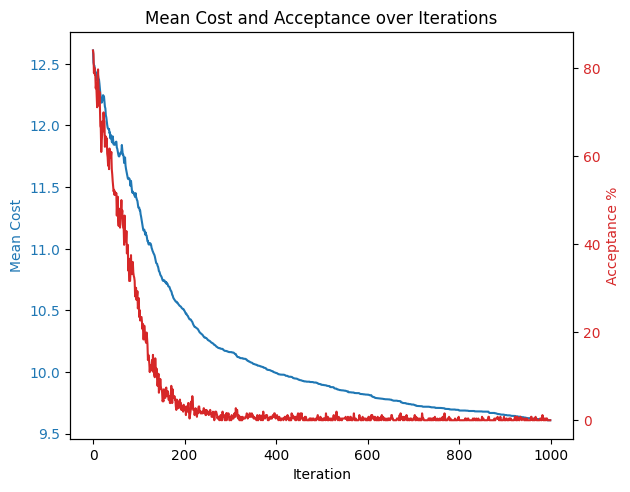

In [13]:
mean = []
accept = []
for cost,acc in zip(costs,acceptance):
    mean.append(torch.mean(cost).item())
    accept.append(torch.sum(acc).item() / len(acc) *100)


import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Mean Cost', color=color)
ax1.plot(mean, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Acceptance %', color=color)
ax2.plot(accept, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Mean Cost and Acceptance over Iterations')
plt.show()

In [9]:
import torch

# Exemple de tenseur
tensor = torch.arange(1,21).repeat(2,1)  # Shape [2, 20]

# Mélanger chaque ligne
shuffled_tensor = torch.stack([row[torch.randperm(row.size(0))] for row in tensor])

# Résultat
print("Tenseur original :")
print(tensor)
print("\nTenseur mélangé :")
print(shuffled_tensor)

# Ajouter un 0 au début de chaque ligne
tensor_with_zero = torch.cat(
    [
        torch.zeros(shuffled_tensor.size(0), 1, dtype=shuffled_tensor.dtype),
        shuffled_tensor,
    ],
    dim=1,
)

# Résultat
print("\nTenseur avec un 0 ajouté au début de chaque ligne :")
print(tensor_with_zero)

Tenseur original :
tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20]])

Tenseur mélangé :
tensor([[20,  9, 19,  7, 10,  6, 13, 12, 14,  1, 18,  5, 17,  8,  4, 16,  2, 15,
         11,  3],
        [ 5, 17,  2,  1, 18, 10,  3, 11, 12,  7, 20, 16,  4, 14,  6,  8,  9, 13,
         19, 15]])

Tenseur avec un 0 ajouté au début de chaque ligne :
tensor([[ 0, 20,  9, 19,  7, 10,  6, 13, 12, 14,  1, 18,  5, 17,  8,  4, 16,  2,
         15, 11,  3],
        [ 0,  5, 17,  2,  1, 18, 10,  3, 11, 12,  7, 20, 16,  4, 14,  6,  8,  9,
         13, 19, 15]])
